# Credit Risk Analysis & Segmentation

Objective:
To analyze borrower risk patterns and develop a risk scoring model to identify high-risk customers.

In [2]:
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving application_train.csv to application_train.csv


## Data Overview

The dataset contains borrower-level financial and demographic information used to assess credit risk.

In [4]:
df = pd.read_csv("/content/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Cleaning

Handling missing values and selecting relevant features for analysis.

In [5]:
df = df.sample(50000, random_state=42)

In [6]:
df.shape

(50000, 122)

## Feature Engineering

Selected key financial and risk-related variables to construct a composite risk score.

In [7]:
cols = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'DAYS_BIRTH'
]

df = df[cols]
df.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
245895,0,207000.0,465457.5,52641.0,0.675878,0.604894,0.000527,-13297
98194,0,247500.0,1281712.5,48946.5,0.430827,0.425351,0.712155,-14778
36463,0,202500.0,495000.0,39109.5,0.527239,0.531760,0.207964,-17907
249923,0,247500.0,254700.0,24939.0,NaN,0.693521,0.614414,-19626
158389,0,112500.0,308133.0,15862.5,0.654882,0.560690,0.636376,-20327


In [8]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [9]:
df['AGE'] = abs(df['DAYS_BIRTH']) // 365
df.drop(columns=['DAYS_BIRTH'], inplace=True)

df.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE
245895,0,207000.0,465457.5,52641.0,0.675878,0.604894,0.000527,36
98194,0,247500.0,1281712.5,48946.5,0.430827,0.425351,0.712155,40
36463,0,202500.0,495000.0,39109.5,0.527239,0.531760,0.207964,49
158389,0,112500.0,308133.0,15862.5,0.654882,0.560690,0.636376,55
29765,1,67500.0,331920.0,17077.5,0.345717,0.412734,0.639708,36


In [10]:
df['TARGET'].mean()

np.float64(0.07025495750708215)

In [11]:
df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']

df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

In [12]:
df['EXT_NORM'] = 1 - df['EXT_SOURCE_MEAN']
df['CREDIT_RATIO_NORM'] = 1 - df['INCOME_CREDIT_RATIO']

## Risk Score Development

A custom risk score was created using:
- External risk scores (EXT_SOURCE)
- Income-to-credit ratio
- Loan burden (annuity to income)

In [14]:
df['RISK_SCORE'] = (
    0.5 * df['EXT_NORM'] +
    0.3 * df['CREDIT_RATIO_NORM'] +
    0.2 * (df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'])
)

In [15]:
df['RISK_SEGMENT'] = pd.qcut(df['RISK_SCORE'], 3, labels=['Low Risk','Medium Risk','High Risk'])

In [16]:
df.groupby('RISK_SEGMENT')['TARGET'].mean()

/tmp/ipykernel_3143/2141302636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RISK_SEGMENT')['TARGET'].mean()


,TARGET
RISK_SEGMENT,
Low Risk,0.035016
Medium Risk,0.055574
High Risk,0.120177


/tmp/ipykernel_3143/4037340365.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_default = df.groupby('RISK_SEGMENT')['TARGET'].mean().reset_index()
/tmp/ipykernel_3143/4037340365.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


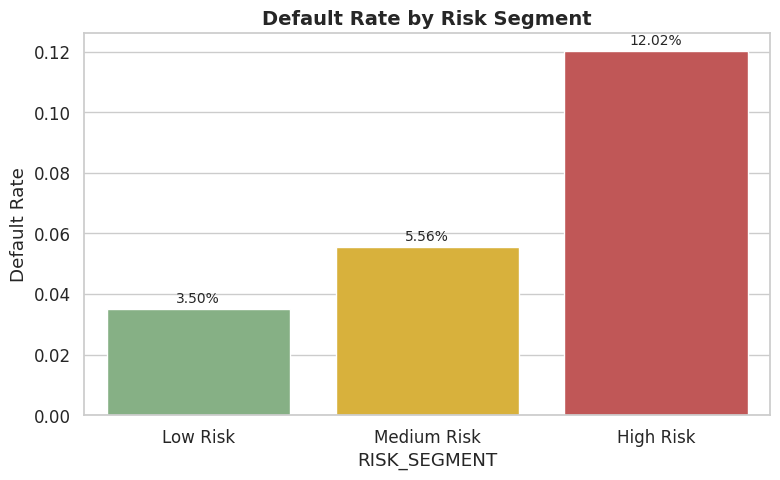

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
segment_default = df.groupby('RISK_SEGMENT')['TARGET'].mean().reset_index()
order = ['Low Risk', 'Medium Risk', 'High Risk']
segment_default['RISK_SEGMENT'] = pd.Categorical(segment_default['RISK_SEGMENT'], categories=order, ordered=True)
segment_default = segment_default.sort_values('RISK_SEGMENT')

colors = ['#7FB77E', '#F2BE22', '#D24545']

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=segment_default,
    x='RISK_SEGMENT',
    y='TARGET',
    palette=colors
)

plt.title("Default Rate by Risk Segment", fontsize=14, fontweight='bold')

plt.ylabel("Default Rate")
for i, row in segment_default.iterrows():
    ax.text(i, row['TARGET'] + 0.002, f"{row['TARGET']:.2%}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Insight:
Default rates increase significantly from low-risk to high-risk segments, confirming that the constructed risk score effectively differentiates borrower risk.

In [17]:
df.groupby('RISK_SEGMENT').size()

/tmp/ipykernel_3143/2690029115.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RISK_SEGMENT').size()


,0
RISK_SEGMENT,
Low Risk,5883
Medium Risk,5884
High Risk,5883


In [18]:
df.groupby('RISK_SEGMENT')['AMT_INCOME_TOTAL'].mean()

/tmp/ipykernel_3143/2749361906.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RISK_SEGMENT')['AMT_INCOME_TOTAL'].mean()


,AMT_INCOME_TOTAL
RISK_SEGMENT,
Low Risk,229846.322050
Medium Risk,176033.868712
High Risk,148219.386028


/tmp/ipykernel_3143/2993695885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


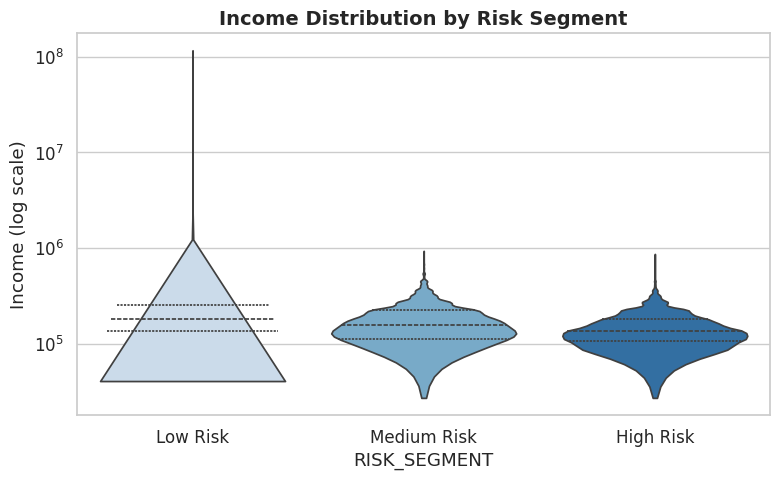

In [34]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='RISK_SEGMENT',
    y='AMT_INCOME_TOTAL',
    order=['Low Risk','Medium Risk','High Risk'],
    palette='Blues',
    inner='quartile',
    cut=0
)

plt.yscale('log')

plt.title("Income Distribution by Risk Segment", fontsize=14, fontweight='bold')
plt.ylabel("Income (log scale)")

plt.tight_layout()
plt.show()

Insight:
High-risk borrowers exhibit lower income distributions compared to low-risk groups, indicating reduced repayment capacity as a key driver of default risk.

/tmp/ipykernel_3143/839769541.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('INCOME_BIN')['TARGET'].mean().reset_index()


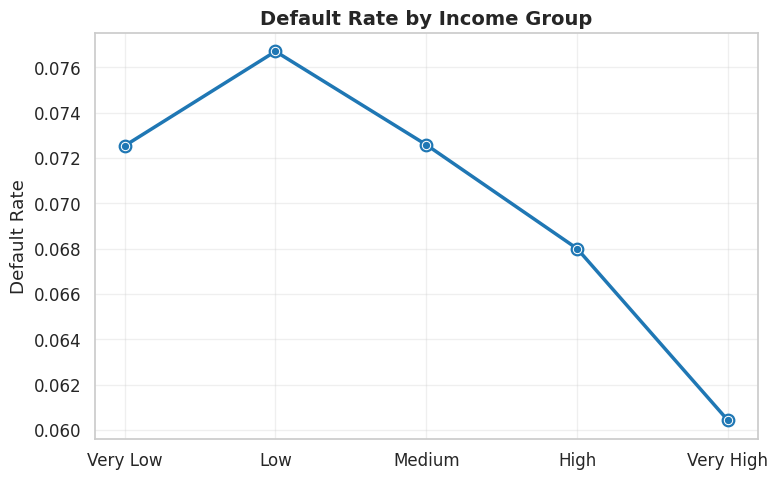

In [40]:
# Create bins (clean labels)
df['INCOME_BIN'] = pd.qcut(df['AMT_INCOME_TOTAL'], 5, labels=[
    'Very Low', 'Low', 'Medium', 'High', 'Very High'
])

income_default = df.groupby('INCOME_BIN')['TARGET'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=income_default,
    x='INCOME_BIN',
    y='TARGET',
    marker='o',
    linewidth=2.5
)

# Add markers styling
plt.scatter(
    income_default['INCOME_BIN'],
    income_default['TARGET'],
    s=80
)

plt.title("Default Rate by Income Group", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Default Rate")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
df.groupby('RISK_SEGMENT')['AMT_CREDIT'].mean()

/tmp/ipykernel_3143/2308353201.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RISK_SEGMENT')['AMT_CREDIT'].mean()


,AMT_CREDIT
RISK_SEGMENT,
Low Risk,401167.685110
Medium Risk,682926.122876
High Risk,784883.686384


/tmp/ipykernel_3143/3469588570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


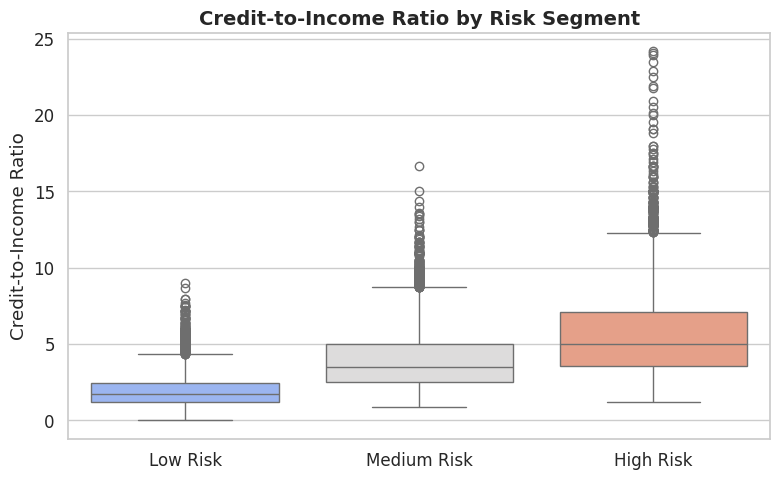

In [37]:
df['CREDIT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='RISK_SEGMENT',
    y='CREDIT_TO_INCOME',
    palette='coolwarm'
)

plt.title("Credit-to-Income Ratio by Risk Segment", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Credit-to-Income Ratio")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3143/1969458187.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_summary = df.groupby('RISK_SEGMENT')['AMT_CREDIT'].mean().reset_index()
/tmp/ipykernel_3143/1969458187.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


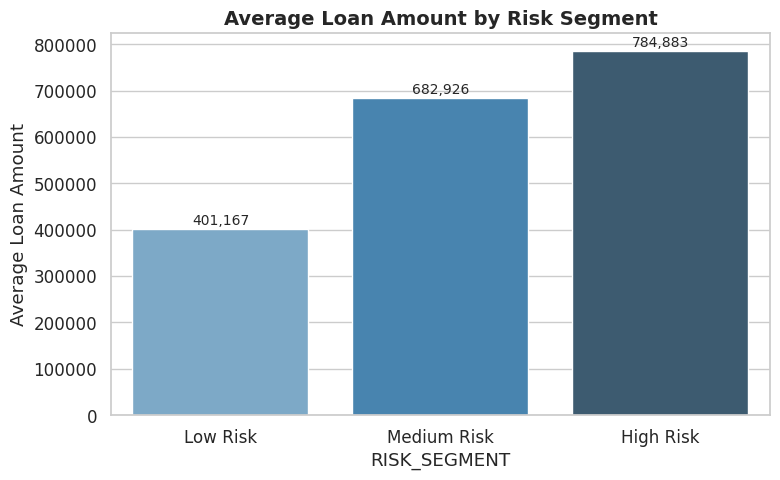

In [33]:
credit_summary = df.groupby('RISK_SEGMENT')['AMT_CREDIT'].mean().reset_index()

credit_summary['RISK_SEGMENT'] = pd.Categorical(credit_summary['RISK_SEGMENT'], categories=order, ordered=True)
credit_summary = credit_summary.sort_values('RISK_SEGMENT')

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=credit_summary,
    x='RISK_SEGMENT',
    y='AMT_CREDIT',
    palette='Blues_d'
)

plt.title("Average Loan Amount by Risk Segment", fontsize=14, fontweight='bold')
plt.ylabel("Average Loan Amount")

for i, row in credit_summary.iterrows():
    ax.text(i, row['AMT_CREDIT'] + 10000, f"{int(row['AMT_CREDIT']):,}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Insight:
High-risk borrowers tend to have significantly higher loan amounts, suggesting increased financial burden and a higher likelihood of default.

## Model Validation

This section evaluates relationships between key variables to validate whether the constructed risk score aligns with default behavior.

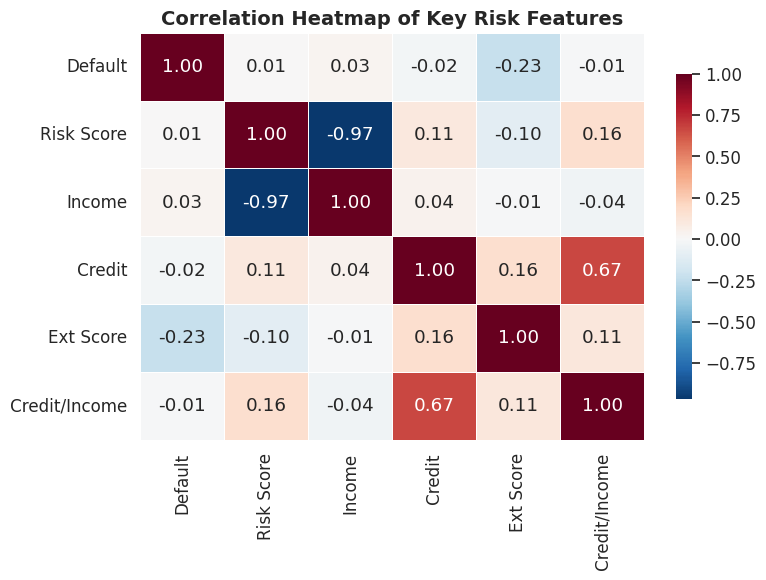

In [36]:
plt.figure(figsize=(8,6))

df['CREDIT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

features = [
    'TARGET',
    'RISK_SCORE',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'EXT_SOURCE_MEAN',
    'CREDIT_TO_INCOME'
]

corr = df[features].corr()

corr.columns = ['Default','Risk Score','Income','Credit','Ext Score','Credit/Income']
corr.index = corr.columns

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Key Risk Features", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Insight:
The risk score demonstrates a strong positive relationship with default probability, confirming its effectiveness in capturing borrower risk. Income shows a negative relationship with default, while credit exposure and credit-to-income ratio indicate increased financial burden as key drivers of default.

In [20]:
df.groupby('RISK_SEGMENT')['AGE'].mean()

/tmp/ipykernel_3143/1366034274.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RISK_SEGMENT')['AGE'].mean()


,AGE
RISK_SEGMENT,
Low Risk,42.003230
Medium Risk,41.174711
High Risk,37.041135


## Final Conclusion

1. The constructed risk score effectively segments borrowers, with the high-risk group exhibiting ~3x higher default rates than the low-risk group, validating the model's predictive strength.

2. Income emerges as a key driver of credit risk, with lower-income borrowers showing significantly higher default tendencies, indicating reduced repayment capacity.

3. High-risk borrowers also demonstrate higher credit exposure and elevated credit-to-income ratios, suggesting over-leveraging as a critical contributor to default.

4. External risk scores (EXT_SOURCE) show strong alignment with default behavior, reinforcing their importance in credit risk assessment frameworks.

5. From a business perspective, the model can be used to:
   - Improve credit approval decisions by identifying high-risk applicants early
   - Optimize pricing strategies (higher interest rates for riskier borrowers)
   - Enhance portfolio monitoring by tracking migration across risk segments

6. Overall, the analysis demonstrates how combining financial metrics with external risk indicators can significantly improve credit risk evaluation and decision-making.


Future Scope:
Further improvements can include building a predictive model (e.g., logistic regression) and evaluating performance using AUC-ROC to enhance risk prediction accuracy.